# 라이브러리 설치 및 불러오기

In [1]:
!pip install yfinance --quiet

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# 한글 폰트 깨짐 방지 (Colab 환경)
plt.rcParams['axes.unicode_minus'] = False

# 데이터 수집
- 티커 검색하기 : https://www.google.com/finance/beta

In [5]:
# ===== 여기만 수정하세요 =====
ticker = input("분석할 종목 티커를 입력하세요 (예: AAPL, 005930.KS, TSLA): ")
start_date = input("데이터 수집 시작일을 입력하세요 (예: 2020-01-01): ")
end_date = input("데이터 수집 종료일을 입력하세요 (예: 2024-12-31): ")
# ============================

print(f"\n티커: {ticker}")
print(f"기간: {start_date} ~ {end_date}")

분석할 종목 티커를 입력하세요 (예: AAPL, 005930.KS, TSLA): TSLA
데이터 수집 시작일을 입력하세요 (예: 2020-01-01): 2020-01-01
데이터 수집 종료일을 입력하세요 (예: 2024-12-31): 2026-07-05

티커: TSLA
기간: 2020-01-01 ~ 2026-07-05


In [6]:
data = yf.download(ticker, start=start_date, end=end_date)

if data.empty:
    print("데이터를 불러오지 못했습니다. 티커나 기간을 다시 확인해주세요.")
else:
    print(data.head())
    print(f"\n총 {len(data)}개의 관측치가 수집되었습니다.")

/tmp/ipykernel_6045/1106821398.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                             
2020-01-02  28.684000  28.713333  28.114000  28.299999  142981500
2020-01-03  29.534000  30.266666  29.128000  29.366667  266677500
2020-01-06  30.102667  30.104000  29.333332  29.364668  151995000
2020-01-07  31.270666  31.441999  30.224001  30.760000  268231500
2020-01-08  32.809334  33.232666  31.215334  31.580000  467164500

총 1633개의 관측치가 수집되었습니다.


# 종가 시각화

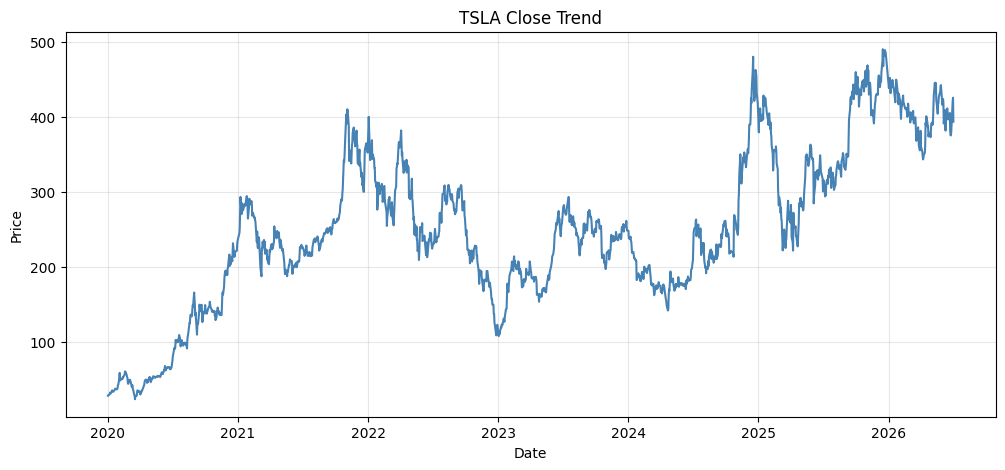

In [8]:
close_price = data['Close']

plt.figure(figsize=(12, 5))
plt.plot(close_price, color='steelblue')
plt.title(f"{ticker} Close Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(alpha=0.3)
plt.show()

In [11]:
result = adfuller(close_price.dropna())
print(f"===== {ticker} ADF 검정 결과 =====")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")

===== TSLA ADF 검정 결과 =====
ADF Statistic : -2.2473
p-value       : 0.1895


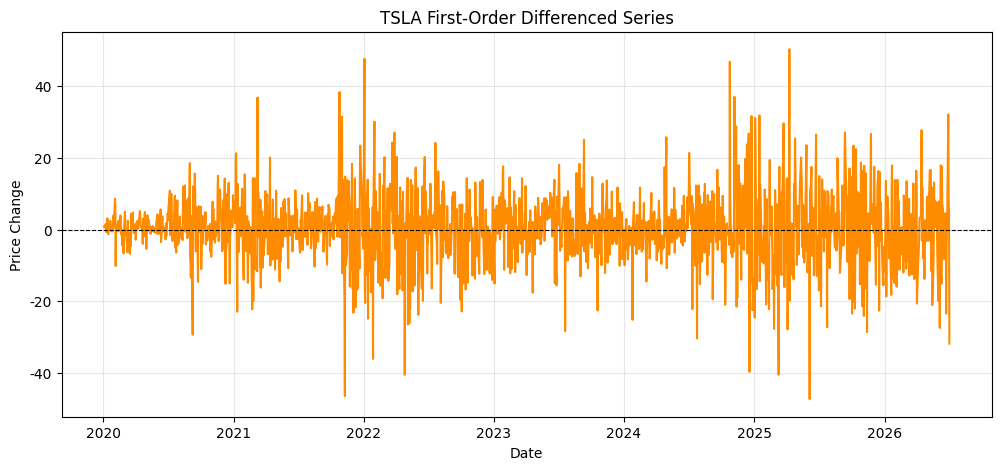

In [12]:
diff_price = close_price.diff().dropna()

plt.figure(figsize=(12, 5))
plt.plot(diff_price, color='darkorange')
plt.title(f"{ticker} First-Order Differenced Series")
plt.xlabel("Date")
plt.ylabel("Price Change")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(alpha=0.3)
plt.show()

In [14]:
result = adfuller(diff_price)
print(f"===== {ticker} ADF 검정 결과 =====")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")

===== TSLA ADF 검정 결과 =====
ADF Statistic : -41.2723
p-value       : 0.0000


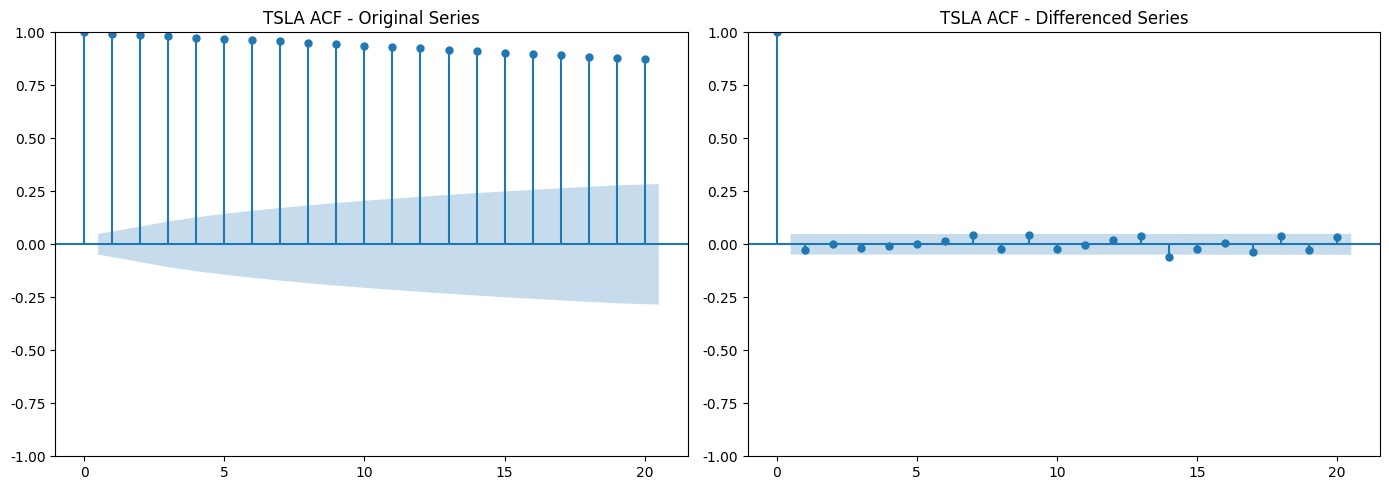

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(close_price.dropna(), lags=20, ax=axes[0])
axes[0].set_title(f"{ticker} ACF - Original Series")

plot_acf(diff_price, lags=20, ax=axes[1])
axes[1].set_title(f"{ticker} ACF - Differenced Series")

plt.tight_layout()
plt.show()

In [17]:
adf_diff_result = adfuller(diff_price)
p_value_diff = adf_diff_result[1]

print("===== 최종 판단 =====")
print(f"종목: {ticker}")
print("확률보행(Random Walk) 모형:  Y_t = Y_(t-1) + ε_t   (ε_t ~ White Noise)")

if p_value_diff <= 0.05:
    print("1차 차분계열이 정상성을 만족합니다.")
    print("=> 원계열은 I(1) 과정을 따르며, ACF가 빠르게 소멸한다면")
    print("   해당 주가는 '랜덤워크(random walk)' 특성을 보인다고 해석할 수 있습니다.")
else:
    print("차분 후에도 정상성이 확보되지 않았습니다.")
    print("=> 추가 차분이나 다른 모형(예: 추세 제거, 계절성 고려)을 검토해야 합니다.")

===== 최종 판단 =====
종목: TSLA
확률보행(Random Walk) 모형:  Y_t = Y_(t-1) + ε_t   (ε_t ~ White Noise)
1차 차분계열이 정상성을 만족합니다.
=> 원계열은 I(1) 과정을 따르며, ACF가 빠르게 소멸한다면
   해당 주가는 '랜덤워크(random walk)' 특성을 보인다고 해석할 수 있습니다.


## 해석

그래프에서 **lag 0을 제외하고는 모든 막대가 파란 신뢰구간(음영) 안에 있습니다.** 이는 통계적으로 유의미한 자기상관이 "하나도 없다"는 뜻

즉, 차분한 계열

$$
\varepsilon_t = Y_t - Y_{t-1}
$$

- 이 **백색잡음(White Noise)** 에 가깝다는 것이 확인된 것이고, 이는 원계열 $Y_t$가 **확률보행(Random Walk)** 을 따른다는 가설을 뒷받침하는 결과
-  **자기상관이 없다 = 과거 값(패턴)으로 미래를 예측할 수 없다**
- 확률보행 모형은 다음과 같습니다.

$$
Y_t = Y_{t-1} + \varepsilon_t
$$

- 여기서 $\varepsilon_t$는 정의상 예측 불가능한 오차이기 때문에, 통계적으로 가장 타당한 예측은:

$$
\hat{Y}_{t+1} = Y_t
$$

- **"내일 주가의 최적 예측값은 오늘 주가와 같다" (naive forecast)** 는 것입니다.